In [5]:
from pcntoolkit.dataio.norm_data import NormData
from pcntoolkit.normative_model import NormativeModel
import pandas as pd
import importlib
import pcntoolkit
importlib.reload(pcntoolkit)
from pcntoolkit.math_functions.thrive import get_correlation_matrix
import matplotlib.pyplot as plt

model = NormativeModel.load("save_dir_SC_all_regions")
#model = model[:, 'Left-Lateral-Ventricle']
test = pd.read_pickle("/Users/johannabayer/Documents/DATA/SC/test_SC_demented_adults_ADNI.pkl")


covariates = ["age"]
batch_effects = ["sex", "site_id2"]

# features_to_model = [
#     'L_bankssts',
# ]


features_to_model = [
    'Left-Lateral-Ventricle',
]


norm_test = NormData.from_dataframe(
    name="test", dataframe=test, covariates=covariates, batch_effects=batch_effects, response_vars=features_to_model
)

norm_test = norm_test.sel(response_vars=features_to_model)

path = "/Users/johannabayer/Documents/Github/PCNtoolkit_Velocity/pcntoolkit/save_dir_SC_all_regions/results/Velocity"
# get correlation matrix
#get_correlation_matrix(norm_test, bandwidth=3, covariate_name="age", matrix_path=path )

model.compute_correlation_matrix(norm_test, bandwidth=5, covariate="age", matrix_path=path)


import numpy as np
import pandas as pd
import xarray as xr
from pcntoolkit import NormData

# Extract structure from existing NormData
response_vars = norm_test.response_vars.to_numpy()
batch_effect_names = norm_test.batch_effects.coords["batch_effect_dims"].to_numpy().tolist()
n_rv = len(response_vars)

# Define grid axes
ages = np.arange(0, 100, 1)
z_scores = np.arange(-4, 4.0, 1)

# All age × Z combinations
age_grid, z_grid = np.meshgrid(ages, z_scores)
age_flat = age_grid.flatten()
z_flat = z_grid.flatten()
n = len(age_flat)

# Build dataframe
df_dict = {
    "age": age_flat,
    "subjects": np.arange(n),
}

# Add one reference value per batch effect from first observation
ref_batch_values = norm_test.batch_effects.isel(observations=500).to_numpy()


for be_name, be_val in zip(batch_effect_names, ref_batch_values):
    df_dict[be_name] = np.full(n, be_val)

# Add dummy response columns
for rv in response_vars:
    df_dict[rv] = np.zeros(n)

df_grid = pd.DataFrame(df_dict)

grid_data = NormData.from_dataframe(
    name="grid",
    dataframe=df_grid,
    covariates=["age"],
    batch_effects=batch_effect_names,
    response_vars=response_vars.tolist(),
    subject_ids="subjects",
)

# Same Z for all response vars at each row
Z = np.tile(z_flat[:, None], (1, n_rv))

grid_data["Z"] = xr.DataArray(
    Z,
    dims=("observations", "response_vars"),
    coords={
        "observations": grid_data.coords["observations"],
        "response_vars": response_vars,
    },
)


ref_batch_values = norm_test.batch_effects.isel(observations=500).to_numpy()
ref_batch_values



Process: 60087 - 2026-05-04 17:52:20 - Dataset "test" created.
    - 50468 observations
    - 50468 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (2)
	site_id2 (125)
    
Process: 60087 - 2026-05-04 17:52:20 - Dataset "grid" created.
    - 800 observations
    - 800 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    


array(['0.0', '23.0'], dtype='<U32')

In [ ]:
model.compute_thrivelines(norm_test, span=5, covariate="age", z_thrive=1.96,grid_data=grid_data, reference_batch_effect={'sex':'1.0', 'site_id': '2.0'}, matrix_path=path)

Sampling: []
Sampling: []


<xarray.NormData> Size: 15MB
Dimensions:            (observations: 50468, response_vars: 1, covariates: 1,
                        batch_effect_dims: 2, offset: 2, dummy_obs: 800)
Coordinates:
  * observations       (observations) int64 404kB 0 1 2 3 ... 50465 50466 50467
  * response_vars      (response_vars) <U22 88B 'Left-Lateral-Ventricle'
  * covariates         (covariates) <U3 12B 'age'
  * batch_effect_dims  (batch_effect_dims) <U8 64B 'sex' 'site_id2'
  * offset             (offset) int64 16B 0 5
  * dummy_obs          (dummy_obs) int64 6kB 0 1 2 3 4 5 ... 795 796 797 798 799
Data variables:
    subject_ids        (observations) int64 404kB 0 1 2 3 ... 50465 50466 50467
    Y                  (observations, response_vars) float64 404kB -0.3521 .....
    X                  (observations, covariates) float64 404kB -1.101 ... 1.04
    batch_effects      (observations, batch_effect_dims) <U32 13MB '1.0' ... ...
    thrive_Z           (dummy_obs, response_vars, offset) float64 13kB -4.0 ....
    thrive_Y           (dummy_obs, response_vars, offset) float64 13kB -1.42 ...
    thrive_X           (dummy_obs, offset) float64 13kB -2.193 -1.975 ... 2.351
Attributes:
    real_ids:                       False
    is_scaled:                      True
    name:                           test
    unique_batch_effects:           {np.str_('sex'): [np.str_('0.0'), np.str_...
    batch_effect_counts:            defaultdict(<function NormData.register_b...
    covariate_ranges:               {np.str_('age'): {'mean': np.float64(37.3...
    batch_effect_covariate_ranges:  {np.str_('sex'): {np.str_('0.0'): {np.str...
    thrive_covariate:               age
    z_thrive:                       1.96

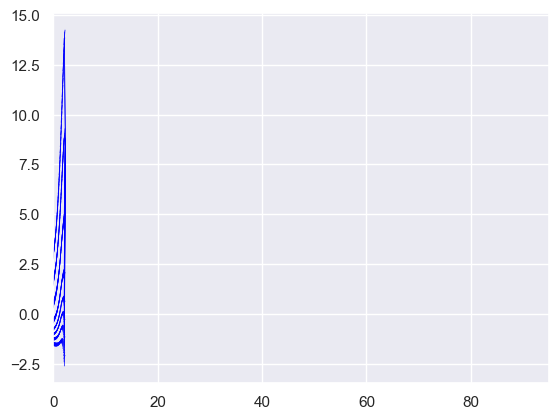

<xarray.DataArray 'thrive_X' (dummy_obs: 800, offset: 2)> Size: 13kB
array([[-2.19337885, -1.97489658],
       [-2.1496824 , -1.93120013],
       [-2.10598594, -1.88750368],
       ...,
       [ 2.04517706,  2.26365933],
       [ 2.08887352,  2.30735578],
       [ 2.13256997,  2.35105223]], shape=(800, 2))
Coordinates:
  * dummy_obs  (dummy_obs) int64 6kB 0 1 2 3 4 5 6 ... 794 795 796 797 798 799
  * offset     (offset) int64 16B 0 5

In [7]:
from pcntoolkit.util.plotter import plot_centiles, plot_centiles_advanced
import matplotlib.pyplot as plt
thrive_Z = norm_test["thrive_Z"]
thrive_X = norm_test["thrive_X"]


import matplotlib.pyplot as plt
import numpy as np

thrive_Z = norm_test["thrive_Z"]
thrive_X = norm_test["thrive_X"]
thrive_Y = norm_test["thrive_Y"]

#thrive_X_raw = model.inscalers["age"].inverse_transform(thrive_X)
#thrive_Y_raw = model.outscalers[features_to_model[0]].inverse_transform(thrive_Y)   


for x, z in zip(thrive_X, thrive_Y):
    plt.plot(np.ravel(x), np.ravel(z), color = "blue", linewidth=0.5)

plt.xlim(0, 95) 
plt.show()


thrive_X

In [5]:
import copy

def subset_model(model, response_vars):
    sub = copy.deepcopy(model)
    sub.response_vars = [rv for rv in response_vars if rv in model.response_vars]
    sub.regression_models = {rv: sub.regression_models[rv] for rv in sub.response_vars}
    sub.outscalers = {rv: sub.outscalers[rv] for rv in sub.response_vars}
    return sub

small_model = subset_model(model, features_to_model)
small_model

Process: 1878 - 2026-04-20 11:21:12 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    
Process: 1878 - 2026-04-20 11:21:12 - Computing centiles for 1 response variables.
Process: 1878 - 2026-04-20 11:21:12 - Computing centiles for Left-Lateral-Ventricle.


Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []


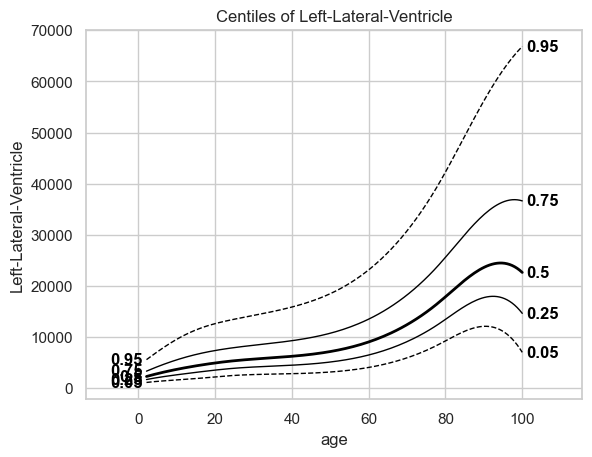

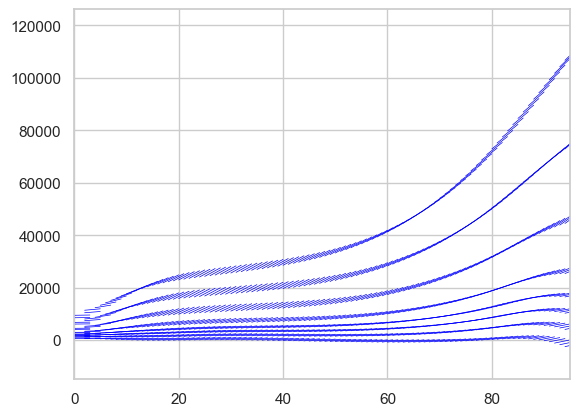

<xarray.DataArray 'thrive_Y' (dummy_obs: 800, response_vars: 1, offset: 2)> Size: 13kB
array([[[5.74011931e+06, 5.87374384e+06]],

       [[5.60307866e+06, 5.75326442e+06]],

       [[5.31790094e+06, 6.12296843e+06]],

       ...,

       [[8.66714520e+08, 9.09881300e+08]],

       [[8.85578213e+08, 5.84511263e+08]],

       [[9.04588457e+08, 5.93724151e+08]]], shape=(800, 1, 2))
Coordinates:
  * dummy_obs      (dummy_obs) int64 6kB 0 1 2 3 4 5 ... 794 795 796 797 798 799
  * response_vars  (response_vars) <U22 88B 'Left-Lateral-Ventricle'
  * offset         (offset) int64 16B 0 3

In [7]:
import matplotlib.pyplot as plt
thrive_Z = norm_test["thrive_Z"]
thrive_X = norm_test["thrive_X"]


import matplotlib.pyplot as plt
import numpy as np

thrive_Z = norm_test["thrive_Z"]
thrive_X = norm_test["thrive_X"]
thrive_Y = norm_test["thrive_Y"]

thrive_X_raw = small_model.inscalers["age"].inverse_transform(thrive_X)
thrive_Y_raw = small_model.outscalers[features_to_model[0]].inverse_transform(thrive_Y)   



plot_centiles_advanced(
    model=small_model,
    response_vars=[features_to_model[0]],     # filtered to known sites
    harmonize_data=False,
)

for x, z in zip(thrive_X, thrive_Y):
    plt.plot(np.ravel(x), np.ravel(z), color = "blue", linewidth=0.5)

plt.xlim(0, 95) 
plt.show()
thrive_Y_raw

